# Corner scans at Heligoland for Range Detection calibration

This notebook contains the analysis for the Test (b) where we measure the distance to a hard target and the water to calibrate the distance for the lidar. 

#### Imports 

In [ ]:
import pathlib 
savepath = pathlib.Path.home()  /'Figures'
savepath.mkdir(exist_ok=True)

In [8]:

from lidalign.io import WindCubeScanDB

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.optimize import curve_fit
from lidalign.utils import publication_figure, load_template
load_template()

Using lidar_monitoring.mplstyle as matplotlib style template


## Load positions from Total Station

In [9]:
import pandas as pd

positions = pd.read_csv('data/HELGOHARB 20250503.csv', header = None, names = ['Position','X','Y','Z','Type'], index_col= 'Position')
pos_rel = positions.copy()
pos_rel[['X','Y','Z']] -= positions.loc['LIDARHEAD',['X','Y','Z']].astype(float)
pos_rel.loc['Watercorner'] = pos_rel.loc['CORNER 2'].copy()
pos_rel = pos_rel.dropna(axis = 0, how = 'any')


# calculate angles
pos_rel['azimuth'] = np.rad2deg(np.arctan2(pos_rel['X'], pos_rel['Y'])) #np.rad2deg(np.arctan2(pos_rel['X'], pos_rel['Y']))
pos_rel['elevation'] =  np.rad2deg(np.arctan(pos_rel['Z'] / (pos_rel['X']**2 + pos_rel['Y']**2)**0.5))

# print(pos_rel)
pos_rel['Distance'] = np.sum(pos_rel[['X','Y','Z']]**2, axis = 1)**0.5
print(pos_rel['Distance']) ## reference is corner2!

aim = pos_rel.loc['Watercorner']

print(aim)

Position
STATION A       20.579809
CORNER 1       171.538760
CORNER 2       171.583166
CORNER 3       157.601132
CORNER 4       143.303444
LIDARLEG1        1.334438
LIDARLEG2        1.294822
LIDARLEG3        1.313251
LIDARHEAD        0.000000
C6             171.523649
C7             171.565801
STATION B        3.764995
Watercorner    171.583166
Name: Distance, dtype: float64
X               168.525
Y               -31.603
Z                -6.431
Type                  P
azimuth      100.621154
elevation      -2.14797
Distance     171.583166
Name: Watercorner, dtype: object


## Read and correct actual measurement data

In [10]:
def angle_offset_function(azimuth, phase, amplitude, offset):
    return np.cos(np.deg2rad(phase + azimuth))* amplitude + offset

azimuth_phase = 322
azimuth_ampl = 0.05
azimuth_offset = 41.86 + 0.38 # 0.38° repositioning offset, theodilite has been moved and not perfectly aligned with first positions

elevation_phase = 80.6
elevation_ampl = 0.08
elevation_offset = 0.29

#### load lidar data

In [ ]:
time_difference_lidar_actual = pd.to_datetime('2025-05-03 10:37') - pd.to_timedelta('2h') - pd.to_datetime('2010-01-02 15:51:32') ## PC time - Lidar time - correction for UTC
time_difference_lidar_actual

p = r"DATAPTH\\" # set your data path here to the shared data
DB = WindCubeScanDB(p, file_structure="flat")


dslist_50 = DB.get_data(start = '2010-01-02 16:02', 
            end = '2010-01-02 17:30', filename_regex = 'ppi.*50m.nc', returnformat = 'xarray')



dslist_25 = DB.get_data(start = '2010-01-02 16:18:46', 
            end = '2010-01-02 16:39:05', filename_regex = 'ppi.*25m.nc', returnformat = 'xarray')


Finding all files for wind_and_aerosols_data
	 --> 142 files found
	 Filtering for 2010-01-02 16:02 to 2010-01-02 17:30, ppi.*50m.nc 
	 --> 59 files found for given regex and time range


Reading files: 100%|██████████| 59/59 [00:01<00:00, 48.35it/s]


	 Filtering for 2010-01-02 16:18:46 to 2010-01-02 16:39:05, ppi.*25m.nc 
	 --> 83 files found for given regex and time range


Reading files: 100%|██████████| 83/83 [00:01<00:00, 43.81it/s]


#### Correct elevation and azimuth for offsets

In [36]:
for ds in dslist_50:
    # ds['azimuth'] = (ds['azimuth'] - azimuth_offset)%360
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360
    ds['elevation'] = ds['elevation'] - angle_offset_function(ds['azimuth'], elevation_phase, elevation_ampl, elevation_offset)
    ds['cnr_linear'] = 10**(ds['cnr']/10)
    ds['time'] = pd.to_datetime(ds['time']) + time_difference_lidar_actual

for ds in dslist_25:
    # ds['azimuth'] = (ds['azimuth'] - azimuth_offset) %360
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360
    ds['elevation'] = ds['elevation'] - angle_offset_function(ds['azimuth'], elevation_phase, elevation_ampl, elevation_offset)
    ds['cnr_linear'] = 10**(ds['cnr']/10)
    ds['time'] =  pd.to_datetime(ds['time']) + time_difference_lidar_actual

## Plot of CNR at Corner

we use here the 50m range gate length. 

25m gives a similar picture BUT: there is a water level change in that time, so you will see some differences (25m was 30 minutes earlier)

The scans for $L_{rg}$=50m took 16minutes

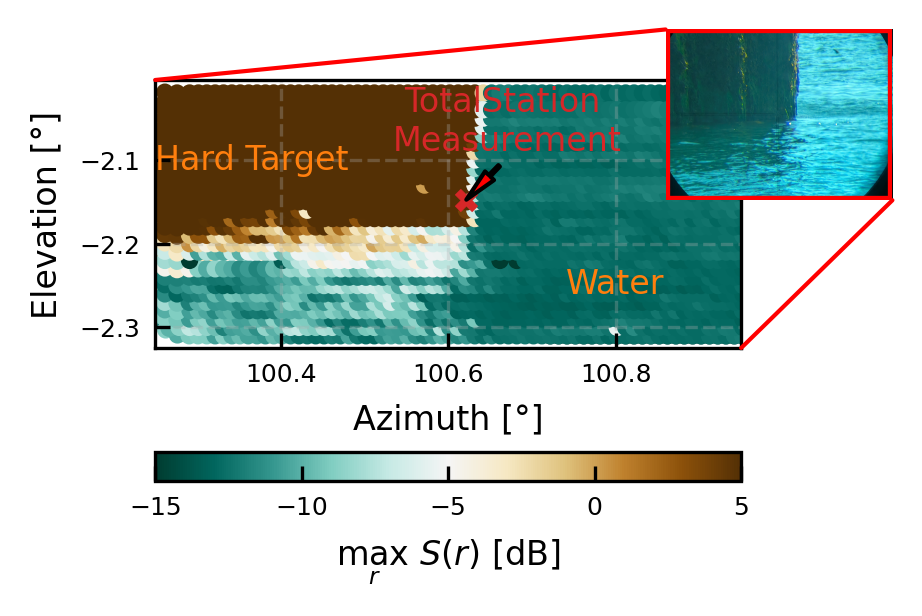

In [37]:
%matplotlib inline
from matplotlib.patches import ConnectionPatch
import matplotlib.image as mpimg
# fig, ax = plt.subplots()
fig, ax = publication_figure(2/5, height = 3)
for dd in dslist_50:
    # swep = Sweep(dd).ds
    swep = dd.copy()
    swep = swep.where(swep['cnr'].max(dim = 'range') > -22, drop = True)
    cnrmax = swep['cnr'].max(dim = 'range')
    cb = ax.scatter(swep['azimuth'], swep['elevation'], c = cnrmax, vmin = -15, vmax = 5, cmap = 'BrBG_r', s = 10)

# xai, yai = 142.85, -2.1#-1.98
ax.set(xlabel = 'Azimuth [°]', ylabel = 'Elevation [°]')#, title = f'CNR map of Corner with Gate length {dd['range_gate_length'].values[0]}m')
# xai, yai = 100.9, -2.1#-1.98

xai, yai = pos_rel.loc['Watercorner', ['azimuth','elevation']]#pos_rel.loc['CORNER 2',['azi','ele']].values
ax.scatter(xai, yai, marker = 'X', c = 'tab:red', s = 30, label = 'Totalstation measurement', lw = 0.1)


xwater, ywater = xai + 0.12, yai - 0.1
# ax.scatter(xwater, ywater, marker = 'P', c = 'tab:orange', s = 50, label = 'Water point')
ax.annotate('TotalStation \nMeasurement', (xai, yai), textcoords="offset points", xytext=(10,12), ha='center', color='tab:red', fontsize=8,arrowprops=dict(facecolor='red', shrink=0.01, headwidth=3, width = 0.5, headlength = 8 ))
ax.text(xwater, ywater, 'Water', color='tab:orange', fontsize=8, verticalalignment='center', horizontalalignment='left')
ax.text(100.25, -2.10, 'Hard Target', color='tab:orange', fontsize=8, verticalalignment='center', horizontalalignment='left')
plt.colorbar(cb, ax = ax, label = r'$\max_{r} \ S(r)$ [dB]', orientation = 'horizontal')
# ax.legend(loc = 'upper right')
ax.set_aspect('equal')
ax.set(xlim = (100.25,100.95))

# import matplotlib.image as mpimg
ax_zoom = fig.add_axes([0.8, 0.45, 0.3, 0.3])  # x0, y0, width, height in figure coords

# # Load an example image
img = mpimg.imread(r"./misc_data/pictures/CornerImage.jpg")  # replace with your image
ax_zoom.imshow(img)
ax_zoom.axis("off")


import matplotlib.patches as patches
h, w = img.shape[:2]
rect = patches.Rectangle(
    (0, 0),                # lower-left corner
    w, h,                  # width and height
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)
ax_zoom.add_patch(rect)


# # ---- Connect the corners ----
xlim, ylim = ax.get_xlim(), ax.get_ylim()

corners_main = [
    (xlim[1], ylim[0]),  # bottom-right
    (xlim[0], ylim[1]),  # top-left
]

corners_zoom = [
    
    (1, 0),
    (0, 1),
    
]

for (xm, ym), (xz, yz) in zip(corners_main, corners_zoom):
    con = ConnectionPatch(
        xyA=(xz, yz), coordsA=ax_zoom.transAxes,
        xyB=(xm, ym), coordsB=ax.transData,
        color="red", lw=1
    )
    fig.add_artist(con)

# plt.show()
plt.savefig(savepath + 'CNRmap_CornerScan_50m.jpg', dpi = 400, bbox_inches = 'tight', pad_inches = 0)

### Approximate height difference between Theodilite measurement and actual water height
From the figure above (and the picture) we can see, that the theodilite did not measure into the water (as it cannot measure the distance here), but slightly above to the quay. Therewith, we must estimate the water level below this measurement point. At the measurements we did, we aimed approx. 0.05° above the water level with the theodilite, at this distance this means there is a height difference of 15cm

In [14]:
heightdiff = np.sin(np.deg2rad(0.03))*pos_rel.loc['Watercorner','Distance']
print(f'Heighdifference is approximately {heightdiff*100:.1f} cm')

Heighdifference is approximately 9.0 cm


### Pulse Analysis results:
The pulse range gate length (25m, 50m, 100m etc.) must be defined as the FWHM, not the gate absolute discrete length. 
Otherwise, the return signal of a hard target is as double as far. 

## Actual Corner evaluation

We determine for all measurerments in the corner scan the range to the hard target (if CNR > CNRht) or to the water (from sigmoid/Convo fits). We can then compare this against our reference model of the wall (harbour quay) and flat plate (of the sea).

In [15]:
# use 50m scans
L_RGuse = 50
# all_ds= xr.concat(dslist_50, dim = 'time')
if L_RGuse==25:
    all_ds= xr.concat(dslist_25, dim = 'time')
elif L_RGuse==50:
    all_ds= xr.concat(dslist_50, dim = 'time')


adjust the linear factor bounds, as we are before the focus point, strong increase of CNR with range in the beginning

In [19]:
from lidalign.SSC import SSC, WaterRangeDetection, GaussianTruncatedPulse
from tqdm import tqdm
savefigs = savepath + "EvalFigures/WallScan/"
verbose = 0
all_dsi = all_ds.copy()
distances = []
plotkw = dict(show_plot= savefigs)
plotkw = dict()
all_kw = dict(lin_factor_bounds = [-0.015, 0.2])
for t in tqdm(all_dsi.time):
    d = all_dsi.sel(time= t)
    if d['cnr'].max()>-0.5: # hard target
        # parameters, _ = curve_fit(truncated_gaussian, d.range.values, d['cnr_linear'].values, p0 = [200, 20, 20,0])
        parameters = GaussianTruncatedPulse.fit_weighting_to_data(d.range.values, d['cnr_linear'].values)
        distances.append(['HardTarget', parameters[0], parameters[0]])
    else: # water range
        ds = d.copy()
        distance_gra24 = WaterRangeDetection(ds, verbose = verbose).get_water_range_from_cnr(func = 'Gra24', **all_kw).r_water
        distance_lin = WaterRangeDetection(ds, verbose = verbose).get_water_range_from_cnr(func = 'LinSig', cnr_noise_cut = -30, **plotkw, **all_kw).r_water
        distance_conv = WaterRangeDetection(ds, verbose = verbose, pulse = GaussianTruncatedPulse(L_RGuse)).get_water_range_from_cnr(func = 'Convo', **all_kw).r_water
        distance_conv_lin = WaterRangeDetection(ds, verbose = verbose, pulse = GaussianTruncatedPulse(L_RGuse)).get_water_range_from_cnr(func = 'LinConvo', **plotkw, **all_kw).r_water
        
        # SSL.get_water_range_from_cnr()
        distances.append(['Water', distance_gra24, distance_lin, distance_conv,distance_conv_lin])


100%|██████████| 4057/4057 [08:05<00:00,  8.36it/s]


## Modeled distances to water and hard target

### Model for sea surface: distance from lidar to water surface

<div class="alert alert-block alert-danger">
<b>Atttention:</b> A correction of the height has to be done, as the theodilite cannot measure exactly the point in the water!
</div>


In [20]:
height_point_over_water = 0.25 if L_RGuse==25 else 0.09 # approximated height of Totalstation measurement point above water level [m] !
lidar_water_distance_model =  (pos_rel.loc['Watercorner','Z']-height_point_over_water)/np.sin(np.deg2rad(all_dsi['elevation']))
%matplotlib inline

### Model for hard target: distance from lidar to quay

 we can estimate the orientation of the wall and the distance of the wall to the lidar.

We utilize this work: https://stackoverflow.com/a/47198877


Distance from lidar to closest point: 100.01  m
Wall direction: -43.67 °


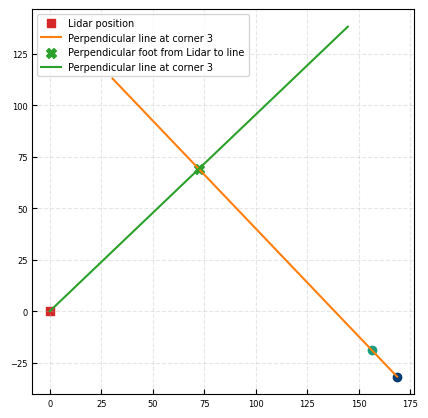

In [21]:
fig, ax = plt.subplots()
c1 = pos_rel.loc['CORNER 1',['X','Y','Z']].values
c3 = pos_rel.loc['CORNER 3',['X','Y','Z']].values
dx,dy,dz = c3-c1
dd = np.array([0,200])
wall_direction = np.rad2deg(np.arctan2(dx, dy))

ax.scatter(*pos_rel.loc['CORNER 1',['X','Y']].values)
ax.scatter(0,0, marker = 's', c = 'tab:red', label = 'Lidar position')
ax.scatter(*pos_rel.loc['CORNER 3',['X','Y']].values)

ax.plot(c1[0]+dd*np.sin(np.deg2rad(wall_direction)), c1[1]+dd*np.cos(np.deg2rad(wall_direction)), c = 'tab:orange', label = 'Perpendicular line at corner 3')
ax.set_aspect('equal')
def p4(p1, p2, p3):
    """Calculate closest point of a given point p3 and a line, defined by points p1 and p2. 
    From: https://stackoverflow.com/a/47198877


    Args:
        p1 (tuple): First point of line
        p2 (tuple): Second point of line
        p3 (tuple): Point to find closest point on line for

    Returns:
        tuple: Closest point on line to p3
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    dx, dy = x2-x1, y2-y1
    det = dx*dx + dy*dy
    a = (dy*(y3-y1)+dx*(x3-x1))/det
    return x1+a*dx, y1+a*dy
p_perp = p4(c1[:2], c3[:2], np.array([0,0]))
p_perp
ax.scatter(*p_perp, marker = 'X', c = 'tab:green', s = 50, label = 'Perpendicular foot from Lidar to line')
dist_lidar_wall = ((p_perp[0])**2 + (p_perp[1])**2)**0.5
print(f'Distance from lidar to closest point: {dist_lidar_wall:.2f}  m')
print(f'Wall direction: {wall_direction:.2f} °')

ax.plot(0+dd*np.sin(np.deg2rad(wall_direction+90)), 0+dd*np.cos(np.deg2rad(wall_direction+90)), c = 'tab:green', label = 'Perpendicular line at corner 3')
ax.legend()


In [22]:
# Test:
azi = pos_rel.loc['CORNER 3','azimuth']
ele = pos_rel.loc['CORNER 3','elevation']
distance_hardtarget_estimated = np.abs(dist_lidar_wall / (np.sin(np.deg2rad(azi - (wall_direction))) * np.cos(np.deg2rad(ele))))
print(distance_hardtarget_estimated)

print(pos_rel.loc['CORNER 3','Distance'])

157.60113248328085
157.60113248328085


In [23]:
hardtarget_distance_model = np.abs(dist_lidar_wall / (np.sin(np.deg2rad(all_dsi['azimuth'] - wall_direction)) * np.cos(np.deg2rad(all_dsi['elevation']))))

### Final Combination of both

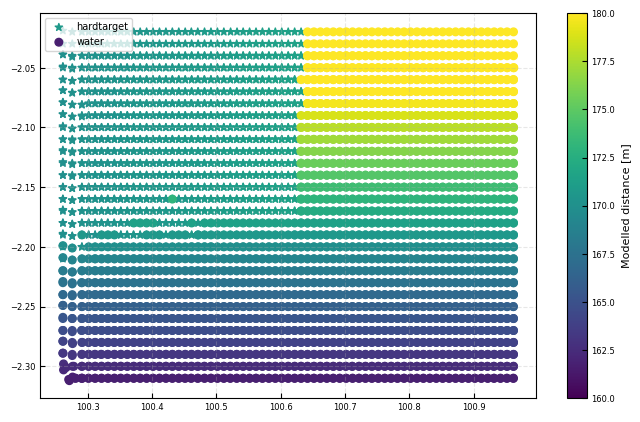

In [24]:
hardtarget_mask = (all_dsi['cnr'].max(dim = 'range')>0).values
water_mask = ~hardtarget_mask
modeldist = np.where(hardtarget_mask, hardtarget_distance_model, lidar_water_distance_model) # correction for height of point above water
# height correction:
fig, ax = plt.subplots()

kw = dict(vmin = 160,vmax = 180, cmap = 'viridis')
ax.scatter(all_dsi['azimuth'][hardtarget_mask], all_dsi['elevation'][hardtarget_mask], c = modeldist[hardtarget_mask], s = 30, marker = '*', label = 'hardtarget', **kw)
cb = ax.scatter(all_dsi['azimuth'][water_mask], all_dsi['elevation'][water_mask], c = modeldist[water_mask], s = 30, marker = 'o', label = 'water', **kw)
plt.colorbar(cb, ax = ax, label = 'Modelled distance [m]')
ax.legend()

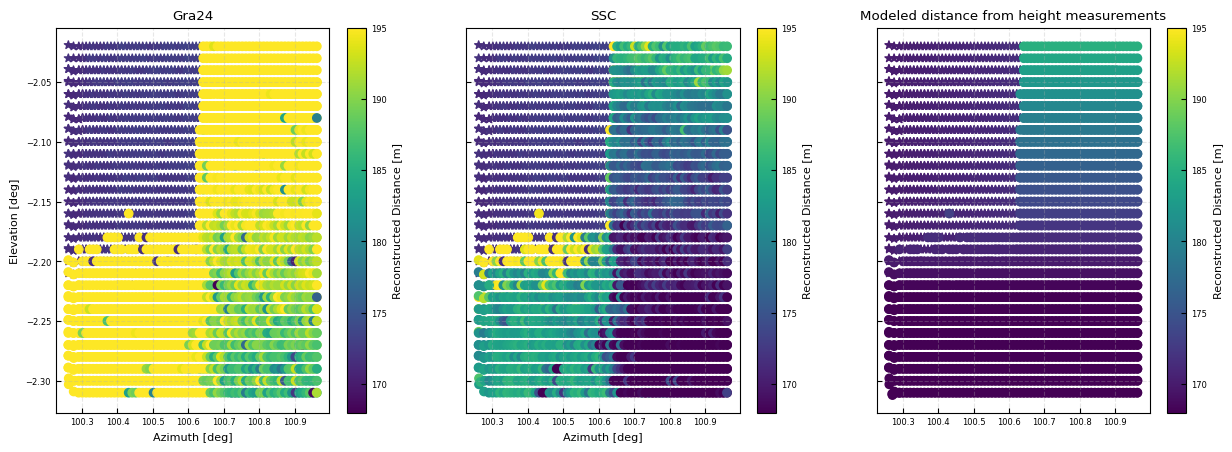

In [25]:

dfparams = pd.DataFrame(distances, columns = ['Type','DistanceGra24','DistanceLinSig','DistanceConv','DistanceConvLin'], index = all_dsi.time)
dfparams.index.name = 'time'




for param in dfparams.columns:
    all_dsi[param] =dfparams[param]


x,y = all_dsi['azimuth'], all_dsi['elevation']
fig, [ax, axdb, axe] = plt.subplots(ncols = 3, sharex = True, sharey = True, figsize = (15,5 ))
kw = dict(vmin = 168, vmax = 195)


cb= ax.scatter(x, y, c= np.where(hardtarget_mask, all_dsi['DistanceGra24'], np.nan), marker = '*', **kw)#, vmin = 170, vmax = 190)
cb= ax.scatter(x, y, c= np.where(water_mask, all_dsi['DistanceGra24'], np.nan), **kw)#, vmin = 170, vmax = 190)


plt.colorbar(cb, ax = ax, label = 'Reconstructed Distance [m]')


cb= axdb.scatter(x, y, c= np.where(hardtarget_mask, all_dsi['DistanceLinSig'], np.nan), marker = '*', **kw)#, vmin = 170, vmax = 190)
cb= axdb.scatter(x, y, c= np.where(water_mask, all_dsi['DistanceLinSig'], np.nan), **kw)#, vmin = 170, vmax = 190)
# cb = axdb.scatter(x,y, c =  all_dsi['Distance_cnr'], **kw)
# mask = (~np.isnan(x) & ~np.isnan(y) & ~np.isnan(all_dsi['Distance_cnr']))
# xnonan, ynonan, cnonan = x[mask], y[mask], all_dsi['Distance_cnr'][mask]
# cb = axdb.tricontourf(xnonan, ynonan, cnonan, **kw)
plt.colorbar(cb, ax = axdb, label = 'Reconstructed Distance [m]')
ax.set(xlabel = 'Azimuth [deg]', ylabel = 'Elevation [deg]', title = 'Gra24')
axdb.set(xlabel = 'Azimuth [deg]', title = 'SSC')


# ---------------------- calculate the modeled distances --------------------- #



cb= axe.scatter(x, y, c= np.where(hardtarget_mask, modeldist, np.nan), marker = '*', **kw)#, vmin = 170, vmax = 190)
cb= axe.scatter(x, y, c= np.where(water_mask, modeldist, np.nan), **kw)#, vmin = 170, vmax = 190)
axe.set(title = 'Modeled distance from height measurements')
# axe.set(title = 'Expected distances')

# ax.scatter(*pos_rel.loc['Watercorner',['azimuth','elevation']],  marker = 'x', c = 'tab:red')
plt.colorbar(cb, ax = axe, label = 'Reconstructed Distance [m]')


## Direct comparison and error calculation

[Text(0.5, 0, 'Azimuth [deg]'), Text(0.5, 1.0, 'LinConvo')]

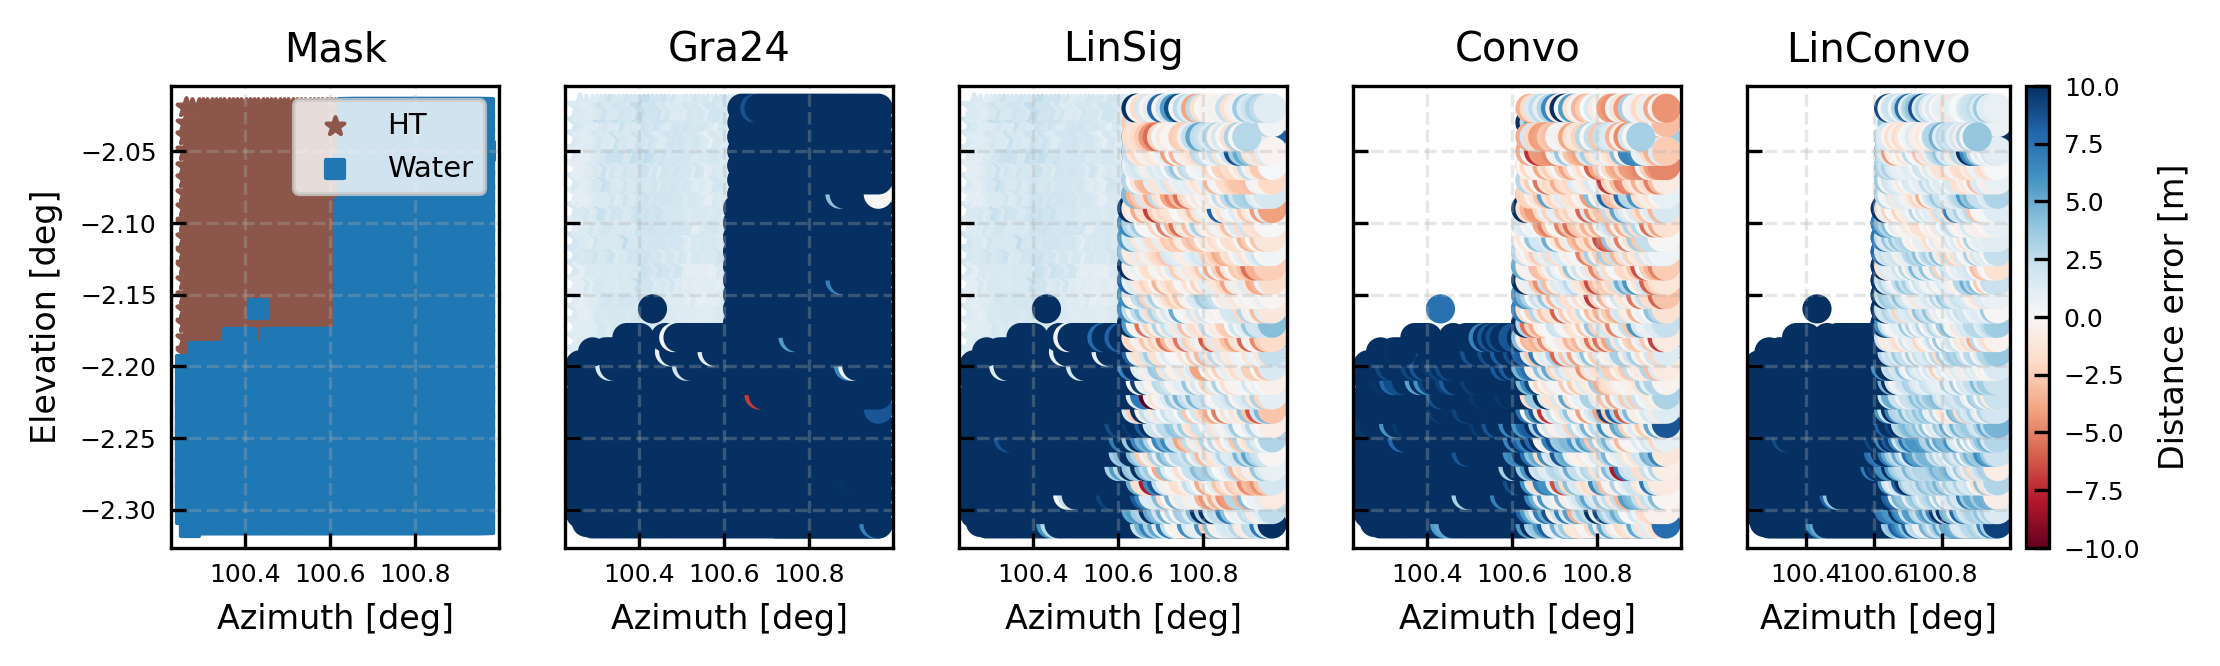

In [26]:
#%%
# fig, [axc, ax, axdb] = plt.subplots(ncols = 3, sharex = True, sharey = True, figsize = (12,4 ))
fig, [axc, ax, axdb, axconvo, axconvolin] = publication_figure(1.3, height = 2, ncols = 5, sharex = True, sharey = True)
# k
kw = dict(vmin = -10, vmax = 10, cmap = 'RdBu')
# kw = dict(vmin = -20, vmax = 20, cmap = 'RdBu')

cb = axc.scatter(x[hardtarget_mask],y[hardtarget_mask], marker = '*', label = 'HT', c = 'tab:brown', s = 20)
cb = axc.scatter(x[water_mask],y[water_mask],marker = 's', label = 'Water', c = 'tab:blue', s = 20)
axc.legend(loc = 'upper right')
axc.set(xlabel = 'Azimuth [deg]', ylabel = 'Elevation [deg]', title = 'Mask')


cb = ax.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceGra24']-modeldist, np.nan),marker = '*', **kw)
cb = ax.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceGra24']-modeldist, np.nan), **kw)
# plt.colorbar(cb, ax = ax, label = 'Distance error [m]')


cb = axdb.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceLinSig']-modeldist, np.nan),marker = '*', **kw)
cb = axdb.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceLinSig']-modeldist, np.nan), **kw)


cb = axconvo.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceConv']-modeldist, np.nan),marker = '*', **kw)
cb = axconvo.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceConv']-modeldist, np.nan), **kw)


cb = axconvolin.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceConvLin']-modeldist, np.nan),marker = '*', **kw)
cb = axconvolin.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceConvLin']-modeldist, np.nan), **kw)

# cb = axdb.scatter(x,y, c =  all_dsi['Distance_cnr']-modeldist, **kw)
plt.colorbar(cb, ax = axconvolin, label = 'Distance error [m]')

ax.set(xlabel = 'Azimuth [deg]', title = r'Gra24')
axdb.set(xlabel = 'Azimuth [deg]', title = r'LinSig')
axconvo.set(xlabel = 'Azimuth [deg]', title = r'Convo')
axconvolin.set(xlabel = 'Azimuth [deg]', title = r'LinConvo')

# plt.tight_layout()




## Plot for publication: Comparison of obtained range errors

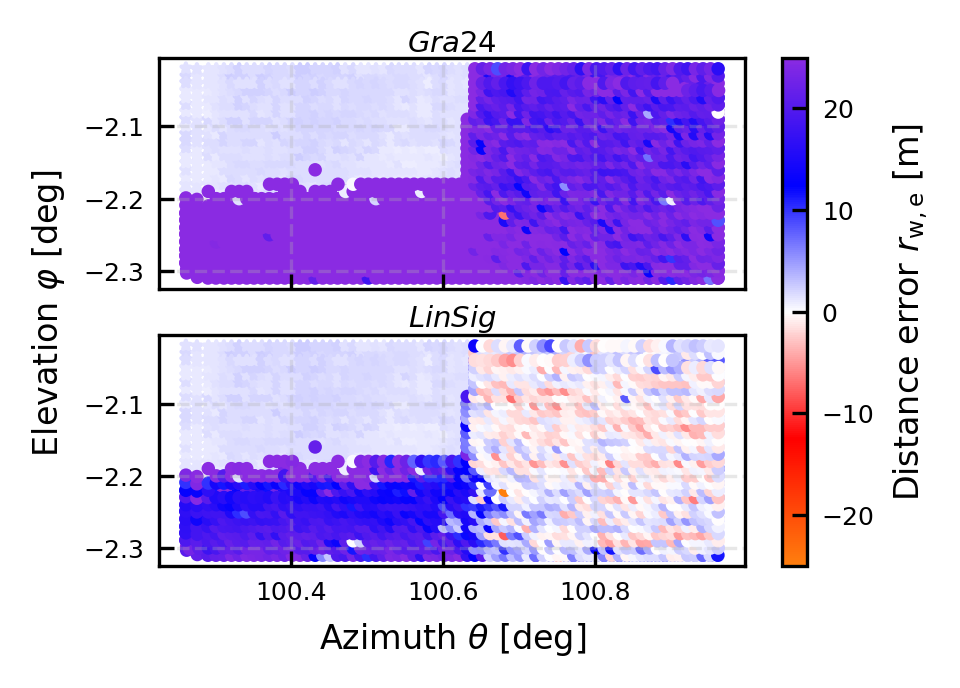

In [27]:
# fig, [axc, ax, axdb] = plt.subplots(ncols = 3, sharex = True, sharey = True, figsize = (12,4 ))
import matplotlib.colors as mcolors
import numpy as np

# Define the color sequence
colors = [
    "blueviolet",
    "blue",
    "white",
    "red",
    "tab:orange"
][::-1]
# Create continuous colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom_purple_blue_white_red_orange",
    colors
)
# cmap = 'RdBu'

# --- Demonstration plot ---
gradient = np.linspace(0, 1, 256).reshape(1, -1)

fig, [ax, axdb] = publication_figure(1/2, height = 2.2, nrows = 2, sharex = True, sharey = True)
# k
kw = dict(cmap = cmap, norm = mcolors.TwoSlopeNorm(vmin=-25, vcenter=0, vmax=25), s = 5)
# kw = dict(cmap = cmap, vmin = -15, vmax = 30, s = 5)
# kw = dict(vmin = -15, vmax = 15, cmap = 'RdBu', s = 5)
# kw = dict(vmin = -20, vmax = 20, cmap = 'RdBu')


cb = ax.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceGra24']-modeldist, np.nan),marker = '*', **kw)
cb = ax.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceGra24']-modeldist, np.nan), **kw)
# plt.colorbar(cb, ax = ax, label = 'Distance error [m]')



cb = axdb.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceLinSig']-modeldist, np.nan),marker = '*', **kw)
# cb = axdb.scatter(x[hardtarget_mask],y[hardtarget_mask], c =  'brown',marker = 'o')
cb = axdb.scatter(x,y, c =  np.where(water_mask, all_dsi['DistanceLinSig']-modeldist, np.nan), **kw)
# cb = axdb.scatter(x,y, c =  all_dsi['Distance_cnr']-modeldist, **kw)
plt.colorbar(cb, ax = [ax, axdb], label = r'Distance error $r_{\rm w,e}$ [m]')

# ax.set(ylabel = r'Elevation $\varphi$ [deg]')
axdb.set(xlabel = r'Azimuth $\theta$ [deg]', ylabel = "\t\t\t  " + r'Elevation $\varphi$ [deg]')

ax.text(0.5,1, r'$Gra24$', transform=ax.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='center')
axdb.text(0.5,1, r'$LinSig$', transform=axdb.transAxes, fontsize=7, verticalalignment='bottom', horizontalalignment='center')

# plt.tight_layout()

plt.savefig(savepath + f'DistanceErrorMaps_HarbourTest_{L_RGuse}m.pdf', bbox_inches = 'tight', pad_inches = 0.)



#### Check distance error against the wall

Median error: 1.663m
IQR error: 0.473m


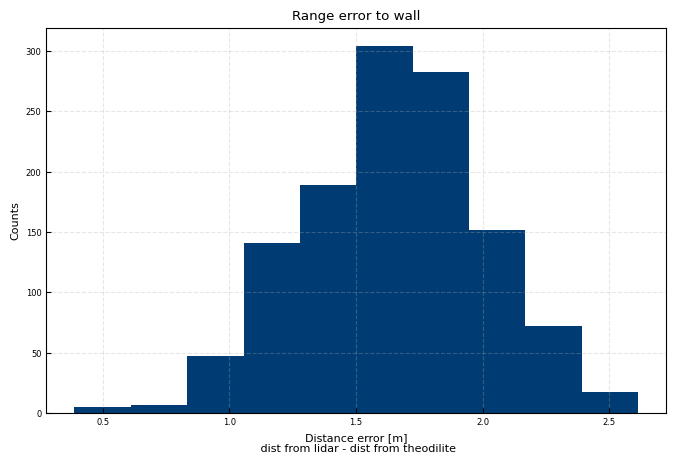

In [28]:
fig, ax = plt.subplots()
wall_distance = np.where(hardtarget_mask, all_dsi['DistanceGra24']-modeldist, np.nan)
ax.hist(wall_distance)
ax.set(title='Range error to wall', xlabel = 'Distance error [m]\n dist from lidar - dist from theodilite', ylabel = 'Counts')
print(f"Median error: {np.nanmedian(wall_distance):.3f}m")
print(f"IQR error: {np.nanpercentile(wall_distance, 75) - np.nanpercentile(wall_distance, 25):.3f}m")


[Text(0.5, 0, 'Azimuth [deg]'),
 Text(0, 0.5, 'Elevation [deg]'),
 Text(0.5, 1.0, 'Distance Error against the wall')]

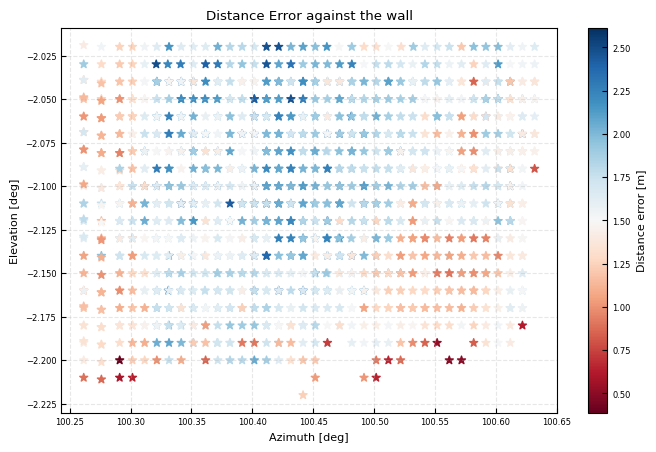

In [29]:

fig, ax = plt.subplots()
cb = ax.scatter(x,y, c =  np.where(hardtarget_mask, all_dsi['DistanceGra24']-modeldist, np.nan),marker = '*', cmap = 'RdBu')
plt.colorbar(cb, ax = ax, label = 'Distance error [m]')
ax.set(xlabel = 'Azimuth [deg]', ylabel = 'Elevation [deg]', title = r'Distance Error against the wall')

## Statistical investigations

DistanceGra24: Median distance error: 22.62 m, Std: 3.51 m, IQR: 3.35 m
DistanceLinSig: Median distance error: 0.84 m, Std: 3.01 m, IQR: 3.24 m
DistanceConv: Median distance error: 0.63 m, Std: 3.19 m, IQR: 3.72 m
DistanceGra25: Median distance error: -2.38 m, Std: 3.51 m, IQR: 3.35 m
DistanceConvLin: Median distance error: 2.51 m, Std: 2.66 m, IQR: 2.85 m


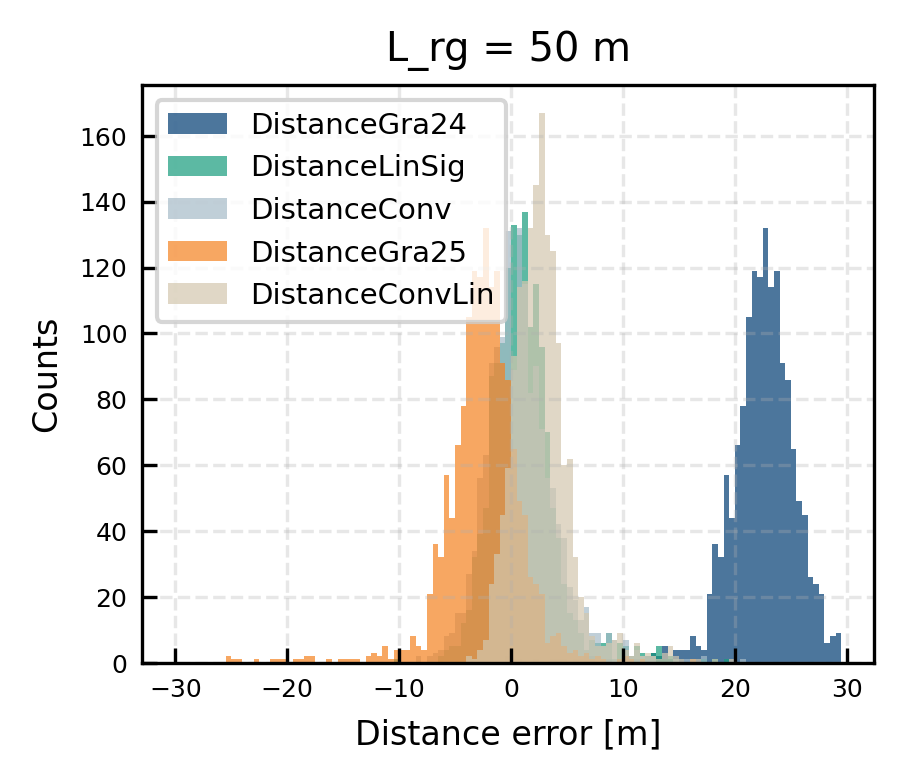

In [30]:
mask_evaluate = (all_dsi['azimuth']>100.7)
# mask_evaluate = (all_dsi['azimuth']<100.6) & (all_dsi['elevation']>-2.15)

fig, ax= publication_figure(1/2, height = 2.5)

all_dsi['DistanceGra25'] = all_dsi['DistanceGra24'] - L_RGuse/2
for var in ['DistanceGra24','DistanceLinSig', 'DistanceConv','DistanceGra25', 'DistanceConvLin']:
    diff = np.where(mask_evaluate, all_dsi[var]-modeldist, np.nan)
    mue = np.nanmean( diff)
    mue = np.median(diff[~np.isnan(diff)])
    ax.hist(diff, bins = np.arange(-30,30,0.5), alpha = 0.7, label = var)
    print(f"{var}: Median distance error: {mue:.2f} m, Std: {np.nanstd(diff):.2f} m, IQR: {np.nanpercentile(diff,75)-np.nanpercentile(diff,25):.2f} m")

ax.legend()
ax.set(title = f"L_rg = {L_RGuse} m", xlabel = 'Distance error [m]', ylabel = 'Counts')
plt.savefig(savepath + f'DistanceErrorHistograms_HarbourTest_{L_RGuse}m.pdf', bbox_inches = 'tight')

# _ = ax.hist(np.where(mask_evaluate, all_dsi['DistanceSSC']-modeldist, np.nan), bins = np.arange(-15,15,0.1), color = 'tab:blue', alpha = 0.7, label = 'SSC')

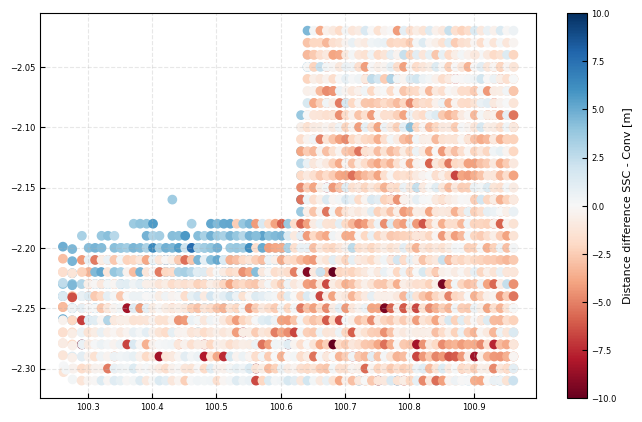

In [31]:
fig, ax = plt.subplots()
cb = ax.scatter(x, y, c=(all_dsi['DistanceLinSig']- all_dsi['DistanceConvLin']), cmap = 'RdBu', vmin = -10, vmax = 10)
plt.colorbar(cb, ax = ax, label = 'Distance difference SSC - Conv [m]')
# np.where(mask_evaluate, all_dsi[var]-modeldist, np.nan)

## Hard Target Pulse shape investigation
Investigation, if the commanded FWHM actually fits with the lidar FWHM when measureing against a hard target

In [32]:
from tqdm import tqdm 


distances_hardtarget = []
small_corner = xr.where(all_ds['cnr'].max(dim = 'range')>5, all_ds, np.nan).dropna(dim = 'time', how = 'all')

for t in tqdm(small_corner.time):
    d = small_corner.sel(time= t)
    # parameters, _ = curve_fit(truncated_gaussian, d.range.values, d['cnr_linear'].values, p0 = [200, 20, 20,0])
    # fwhm, _,_,_ = calculate_FWHM(d.range.values, d['cnr_linear'].values)
    fwhm = GaussianTruncatedPulse.fit_weighting_to_data(d.range.values, d['cnr_linear'].values)
    distances_hardtarget.append([*fwhm])


100%|██████████| 1137/1137 [00:02<00:00, 492.09it/s]


0.9270540130611589


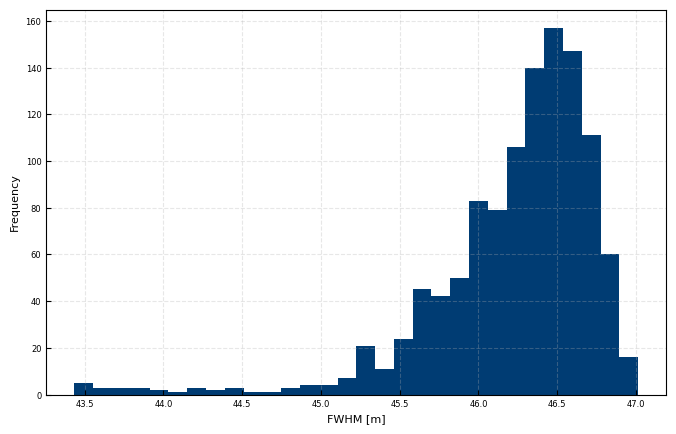

In [33]:
    
dfparams = pd.DataFrame(distances_hardtarget, columns = ['Rmax','CNRmax','FWHM'], index = small_corner.time)
dfparams.index.name = 'time'   
fig, ax = plt.subplots()
# ax.hist(small_corner['Width'], bins = np.arange(0,25,0.1))
# ax.set(xlabel = 'Sigma of Gaussian [m]', ylabel = 'Frequency')

ax.hist(dfparams['FWHM'], bins = 30)#np.arange(35,55,0.5))
ax.set(xlabel = 'FWHM [m]', ylabel = 'Frequency')
print(dfparams['FWHM'].median() / L_RGuse)


## Appendix: vertical and horizontal rows 

[Text(0, 0.5, 'CNR [dB]'), Text(0.5, 0, 'Range [m]')]

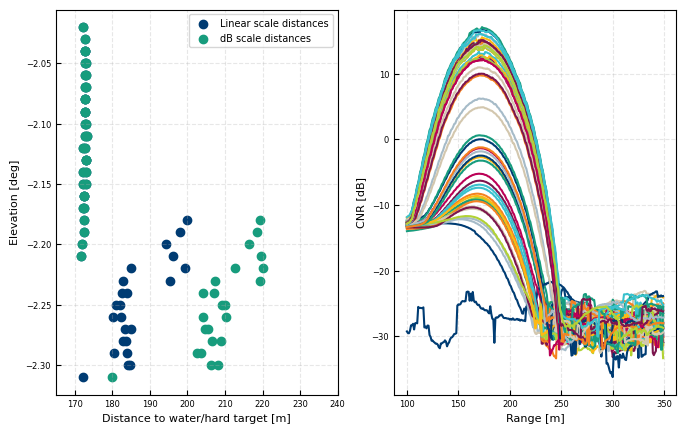

In [39]:
%matplotlib inline
# row = all_dsi.where((all_dsi['elevation']<-2.045) & (all_dsi['elevation']>-2.055), drop = True).copy()
# row['Distance'] = row['Distance'].where(row['Distance']<400)
# fig, ax = plt.subplots()
# ax.scatter(row['azimuth'], row['Distance'])
row = all_dsi.where((all_dsi['azimuth']>100.495) & (all_dsi['azimuth']<100.505), drop = True)
fig, [ax, axc] = plt.subplots(ncols = 2)
ax.scatter(row['DistanceLinSig'], row['elevation'], label = 'Linear scale distances')
ax.scatter(row['DistanceGra24'], row['elevation'], label = 'dB scale distances')
for rt in row.time:
    rti = row.sel(time= rt)
    axc.plot(rti.range, rti['cnr'])

ax.legend()
ax.set(xlabel = 'Distance to water/hard target [m]', ylabel = 'Elevation [deg]')
ax.set(xlim = (165,240))
axc.set(ylabel = 'CNR [dB]', xlabel = 'Range [m]')

[Text(0, 0.5, 'Distance [m]'), Text(0.5, 0, 'Azimuth [deg]')]

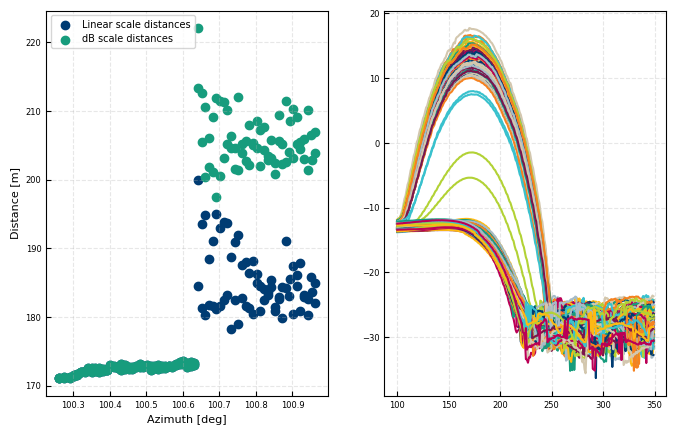

In [40]:
%matplotlib inline
row = all_dsi.where((all_dsi['elevation']<-2.045) & (all_dsi['elevation']>-2.055), drop = True).copy()

# row = all_dsi.where((all_dsi['azimuth']>142.795) & (all_dsi['azimuth']<142.805), drop = True)
fig, [ax, axc] = plt.subplots(ncols = 2)
ax.scatter(row['azimuth'], row['DistanceLinSig'], label = 'Linear scale distances')
ax.scatter(row['azimuth'], row['DistanceGra24'], label = 'dB scale distances')
for rt in row.time:
    rti = row.sel(time= rt)
    axc.plot(rti.range, rti['cnr'])

ax.legend()
ax.set(ylabel = 'Distance [m]', xlabel = 'Azimuth [deg]')